# Python Tutorial for DA5400W: FML
##### TA: Sanved Bangale

Contents: 
Linear Regression (OLS and TLS) and Logarithmic Regression

### Imports, Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

from warnings import filterwarnings, warn
filterwarnings('ignore')

stylesheet = './rose-pine-dawn.mplstyle'
plt.style.use(stylesheet)

In [2]:
np.random.seed(42)

Making data of the form:

$$
y = \beta_0 + \beta_1 x + \text{noise}
$$

Say, $\beta_0 = 5$, and $\beta_1 = 9$.
Meaning, $y = 2 + 3x$.

In [3]:
beta_0 = 5
beta_1 = 9

In [4]:
X = np.linspace(0, 10, 50)
noise = np.random.randn(50)
y = beta_0 + beta_1 * X + noise

In [5]:
def plt_regression(X, y, W=None, title="Plot", X_label='X', y_label='y'):

    plt.scatter(X, y)

    if W is not None:
        plt.plot(np.linspace(X.min(), X.max(), 100), W[0] + W[1] * np.linspace(X.min(), X.max(), 100), linewidth=1, color="#089272")

    plt.title(title)
    plt.xlabel(X_label)
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()

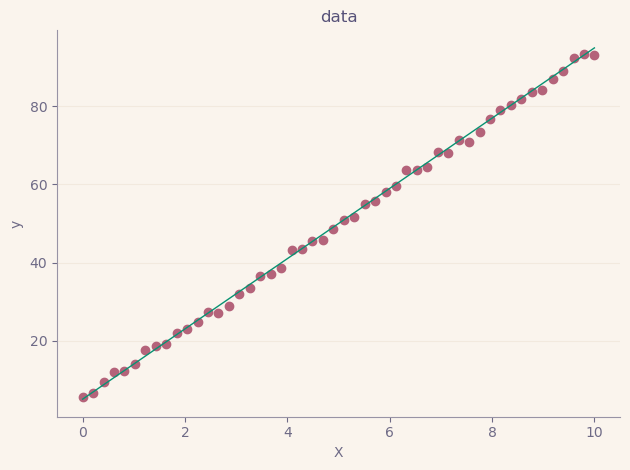

In [6]:
plt_regression(X, y, title='data', X_label='X', y_label='y', W=[beta_0, beta_1])

# Linear Regression

## OLS: Ordinary Least Squares

Input:


$$ \{ x_1, x_2, \dots, x_n \}, \ \ \ \ x_i \in \mathbb{R}^d$$
$$ \{ y_1, y_2, \dots, y_n \}, \ \ \ \ y_i \in \mathbb{R}$$

Goal:
$$h: \mathbb{R}^d \rightarrow \mathbb{R}$$

Error:

$$\text{Error}(h) = \sum_{i=1}^{n} (h(x_i)-y_i)^2$$




We assume a linear relationship between $X$ and $y$.

Our goal is
$$
\min_{w \in \mathbb{R}^d} \sum_{i=1}^{n} \left( w^\top x_i - y_i \right)^2
$$

I'm assuming the following notation:

$X_{d \times n}$ is the feature matrix. \
$w_{d \times 1}$ is the weight vector. \
$y_{n \times 1}$ is the target vector.

In [8]:
# using scikit-learn
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)

print("intercept:", model.intercept_)
print("ceof:", model.coef_[0])

intercept: 5.0644430922029855
ceof: 8.942016600508175


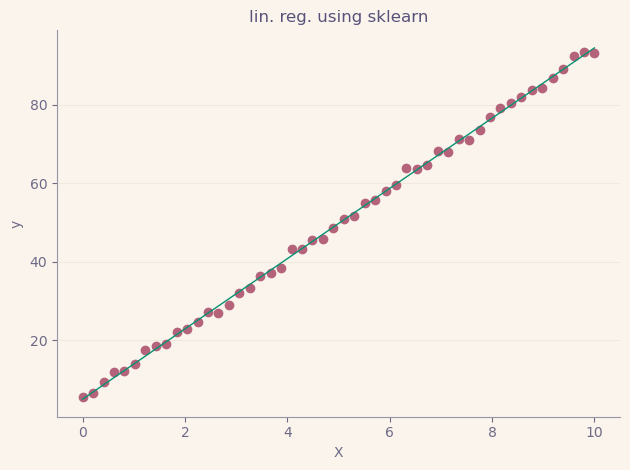

In [9]:
plt_regression(X, y, [model.intercept_, model.coef_[0]], title='lin. reg. using sklearn')

In [25]:
class OrdinaryLeastSquares:
    
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
            
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        
        w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y 
        
        self.intercept_ = w[0]
        self.coef_ = w[1:]
        
    def predict(self, X_new):
        
        X_new = np.asarray(X_new)
        
        if X_new.ndim == 1:
            X_new = X_new.reshape(-1, 1)
            
        return self.intercept_ + X @ self.coef_

In [26]:
model = OrdinaryLeastSquares()
model.fit(X, y)
ols_intercept, ols_coef = model.intercept_, model.coef_

print("intercept:", model.intercept_)
print("ceof:", model.coef_[0])

intercept: 5.06444309220297
ceof: 8.942016600508179


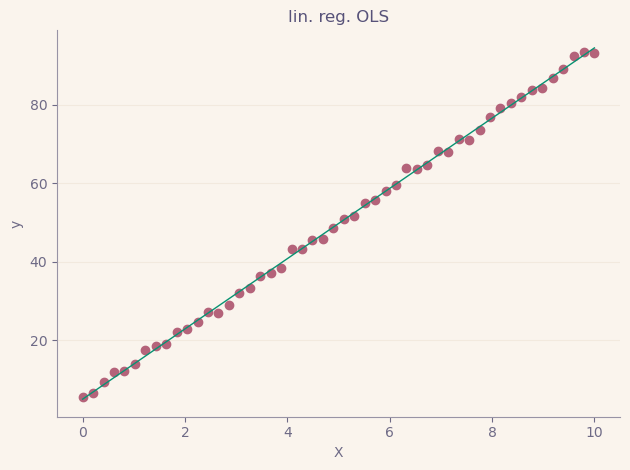

In [27]:
plt_regression(X, y, [ols_intercept, ols_coef], title='lin. reg. OLS')

## TLS: Total Least Squares

In [28]:
class TotalLeastSquares:
    
    def __init__(self):
        self.coef_ = None  
        self.intercept_ = None  
        
    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        X_b = np.hstack([np.ones((X.shape[0], 1)), X])

        A = np.hstack([X_b, y.reshape(-1, 1)])

        U, S, Vt = np.linalg.svd(A)
        V = Vt.T

        v = V[:, -1]

        a = v[:-1]
        b = v[-1]

        w = -a / b

        self.intercept_ = w[0]
        self.coef_ = w[1:]
        
    def predict(self, X_new):
        
        X_new = np.asarray(X_new)
        if X_new.ndim == 1:
            X_new = X_new.reshape(-1, 1)
            
        return self.intercept_ + X @ self.coef_

In [29]:
model = TotalLeastSquares()
model.fit(X, y)
tls_intercept, tls_coef = model.intercept_, model.coef_

print("intercept:", tls_intercept)
print("ceof:", tls_coef)

intercept: 5.179774504475307
ceof: [8.9269349]


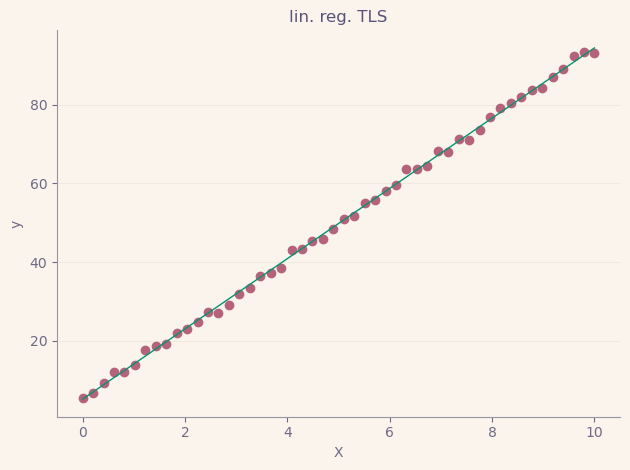

In [30]:
plt_regression(X, y, [tls_intercept, tls_coef], title='lin. reg. TLS')

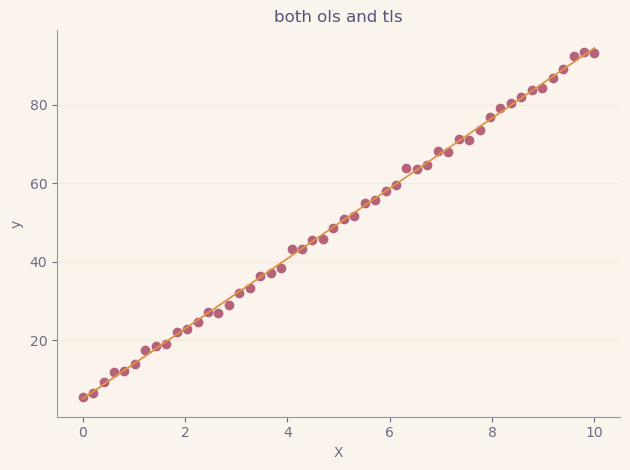

In [31]:
plt.scatter(X, y)

plt.plot(np.linspace(X.min(), X.max(), 100), ols_intercept + ols_coef * np.linspace(X.min(), X.max(), 100), linewidth=1)
plt.plot(np.linspace(X.min(), X.max(), 100), tls_intercept + tls_coef * np.linspace(X.min(), X.max(), 100), linewidth=1)

plt.title('both ols and tls')
plt.xlabel('X')
plt.ylabel('y')
plt.tight_layout()
plt.show()

## Logarithmic Regression

In [39]:
class LogarithmicRegression:
    # for y = a + b·ln(x)
    
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self, X, y):
        
        X = np.asarray(X)
        y = np.asarray(y)
        
        X_log = np.log(X)
        
        if X_log.ndim == 1:
            X_log = X_log.reshape(-1, 1)
            
        X_b = np.hstack([np.ones((X_log.shape[0], 1)), X_log])
        
        w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        
        self.intercept_ = w[0]
        self.coef_ = w[1:]
                
    def predict(self, X_new):
        X_new = np.asarray(X_new)
        
        X_new_log = np.log(X_new)
        
        if X_new_log.ndim == 1:
            X_new_log = X_new_log.reshape(-1, 1)
            
        return self.intercept_ + X_new_log @ self.coef_

In [33]:
X_2 = np.linspace(0.1, 100, 100)
noise = np.random.randn(100)
y_2 = 2 + 5 * np.log(X_2) + noise

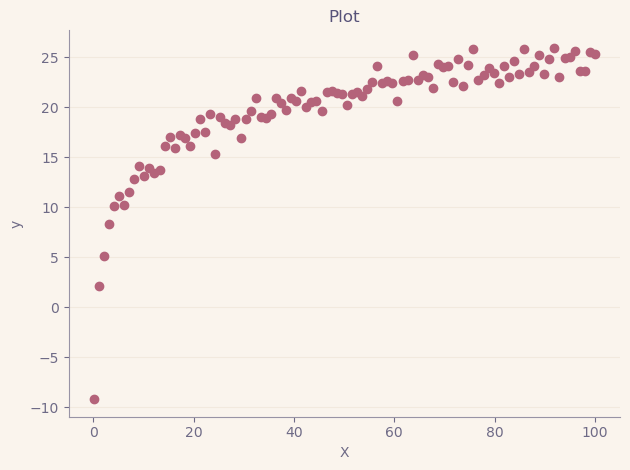

In [34]:
plt_regression(X_2, y_2)

In [35]:
model = LogarithmicRegression()
model.fit(X_2, y_2)
logr_intercept, logr_coef = model.intercept_, model.coef_

print("intercept:", logr_intercept)
print("ceof:", logr_coef)

intercept: 2.166714167922195
ceof: [4.95046031]


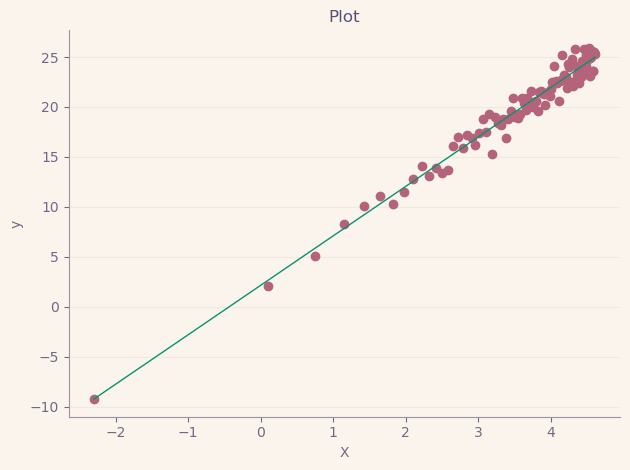

In [36]:
plt_regression(np.log(X_2), y_2, [logr_intercept, logr_coef])

In [37]:
def plt_log_regression(X, y, W=None, title="Plot", X_label='X', y_label='y'):

    plt.scatter(X, y, alpha=0.6)

    if W is not None:
        X_range = np.linspace(X.min(), X.max(), 100)
        y_curve = W[0] + W[1] * np.log(X_range)
        plt.plot(X_range, y_curve, color="#128C53", linewidth=1, label='Log-Fit')
    plt.title(title)
    plt.xlabel(X_label)
    plt.ylabel(y_label)
    plt.tight_layout()
    plt.show()

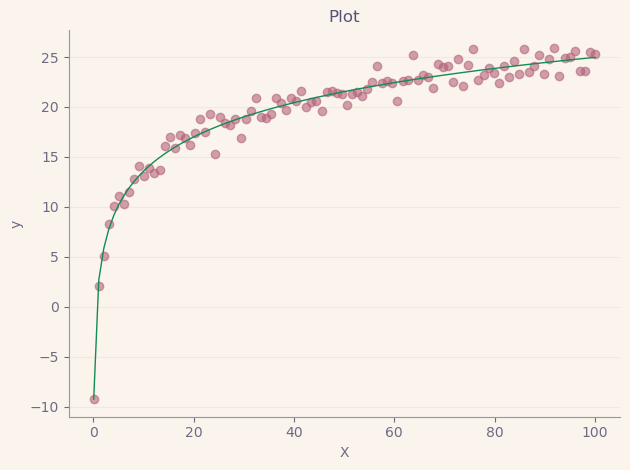

In [38]:
plt_log_regression(X_2, y_2, [logr_intercept, logr_coef])